Used for the statistical analysis of trained models

    * Arguments can be specified in
        * Arguments: Specify data, model, and control settings
        * Post-Generation Time Slicing: Time-slice data *after* generation
        * Analyze Single Traj
        * Autocorrelation Traj: Specify autocorrelation lag value and other settings

Imports

In [10]:
import os
import torch
from src.data_utils import unpickle_data
from src.modeling import HolsteinPARC
from src.analysis_utils import gen_multi_traj, compare_cdw_order_vis, compare_site_vis, compare_cdw_order_autocorrelation, PLTArgs, analyze_cdw_order_div
from src.utils import get_project_root

PROJECT_ROOT = get_project_root()

Arguments

In [2]:
''' Data Args '''

# Path to *.pkl data
data_path: str | os.PathLike = PROJECT_ROOT / "data/generated/L-32-g_0p5_0p8-rd-1e-04-si_64-steps_1200-zero_mom-MID/pickled/test.pkl"

# Slice to use desired number of batches
# use slice(None) to use all
batch_slice: slice = slice(None)
# Determine time range to take. 
sim_start: int | None = 0
sim_end: int | None = None

''' Model Args '''

# Path to *.pth model weights
# A model_kwargs.pkl must exist in the same directory
model_path: str | os.PathLike = PROJECT_ROOT / "pretrained_weights/tiny-quench_0p5_0p8-L_32/model_weights.pth"

''' Control Args '''

max_batch_size: int = 32 # Maximum number of trajectories that can be inferenced at once

Create model

In [3]:
model_kwargs = unpickle_data(os.path.join(os.path.dirname(model_path), "model_kwargs.pkl"))

model = HolsteinPARC(**model_kwargs)

model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu'), weights_only=True))

<All keys matched successfully>

Generate Data

In [4]:
full_labels, full_preds = gen_multi_traj(model, data_path=data_path, batch_slice=batch_slice, max_batch_size=max_batch_size, sim_start=sim_start, sim_end=sim_end)

Post-Generation Time Slicing

In [5]:
# Specify post-gen time slicing. Both None to do nothing
post_gen_start: int | None = None
post_gen_end: int | None  = None


labels = [comp[:, post_gen_start:post_gen_end] for comp in full_labels]
preds = [comp[:, post_gen_start:post_gen_end] for comp in full_preds]

Check for divergence in preds

In [6]:
divs = analyze_cdw_order_div(labels, preds, relative_div_threshold=1.1)

# Check if any rho exceeding
if len(divs.charge_div_idxs) == 0:
    print("No divergent charge order batches!")
else:
    print(f"There are {len(divs.charge_div_idxs)} divergent charge orders on batches:\n", divs.charge_div_idxs.tolist())

# Check if any Q exceeding
if len(divs.lattice_div_idxs) == 0:
    print("No divergent lattice order batches!")
else:
    print(f"There are {len(divs.lattice_div_idxs)} divergent lattice orders on batches:\n", divs.lattice_div_idxs.tolist())

# Total divergent batches
print(f"\nIn total there are {len(divs.combined_div_idxs)} total divergent batches out of {len(labels[0])} total batches:\n", divs.combined_div_idxs.tolist())

No divergent charge order batches!
No divergent lattice order batches!

In total there are 0 total divergent batches out of 64 total batches:
 []


Analyze Single Traj

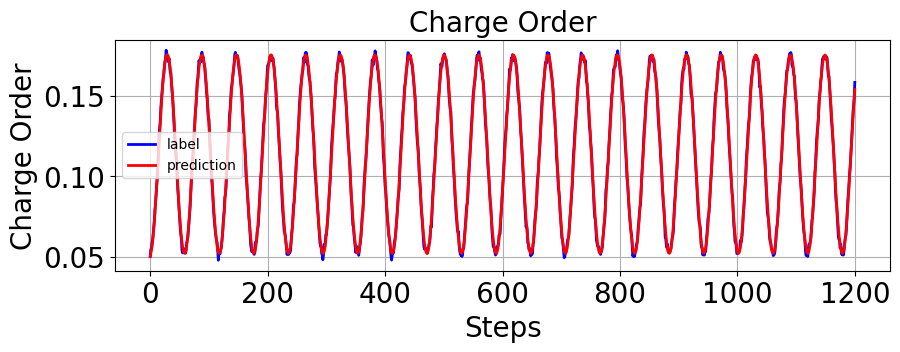

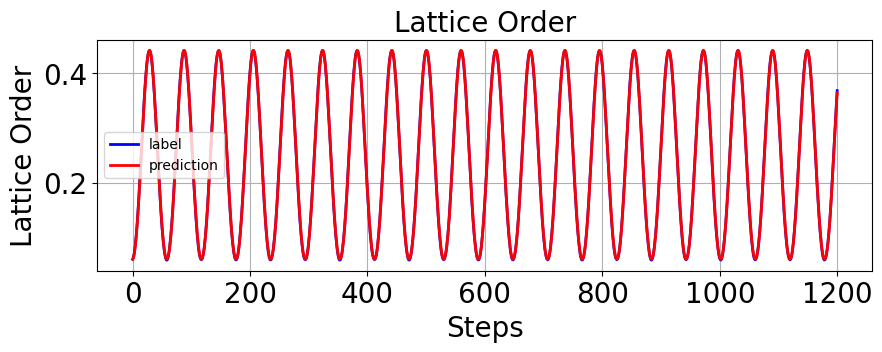

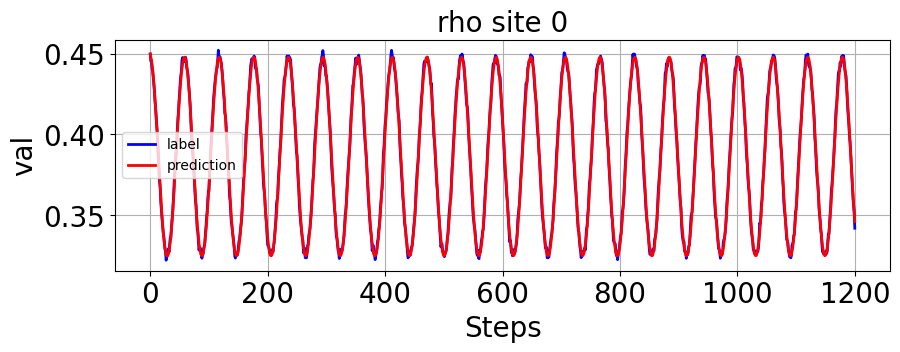

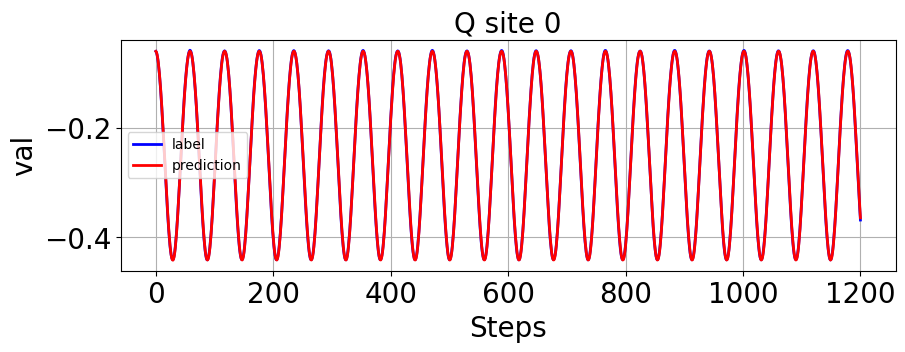

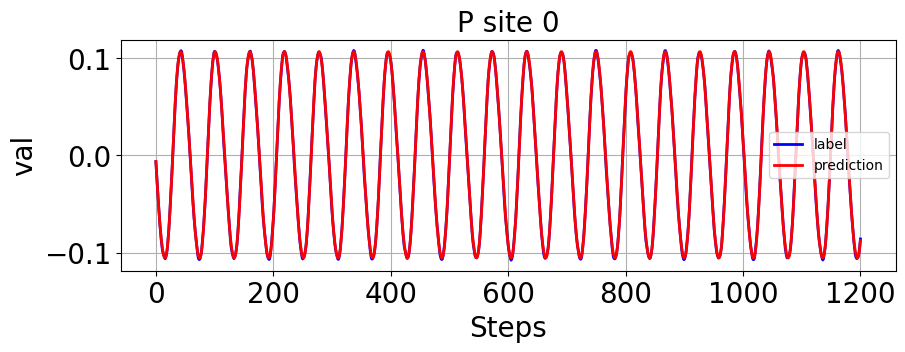

In [7]:
# Specify desired simulation index
sim_idx: int = 0

single_label, single_pred = tuple(comp[sim_idx] for comp in labels), tuple(comp[sim_idx] for comp in preds)
pltargs = PLTArgs(figsize=(10,3), return_image=True)
cdw_order_vis = compare_cdw_order_vis(single_label, single_pred, pltargs=pltargs)
site_vis = compare_site_vis(single_label, single_pred, pltargs=pltargs)

## Uncomment to stitch figures together into one image
# stitch_images_grid([*cdw_order_vis.values(), *site_vis.values()], n_rows=3, n_columns=2)

Filter Divergent Batches Out of Preds

In [8]:
filtered_preds = [comp[~divs.combined_div_mask] for comp in preds]

print(f"Now there are {len(filtered_preds[0])} trajectories left in preds")

Now there are 64 trajectories left in preds


Autocorrelation Traj

Charge order autocorr traj :


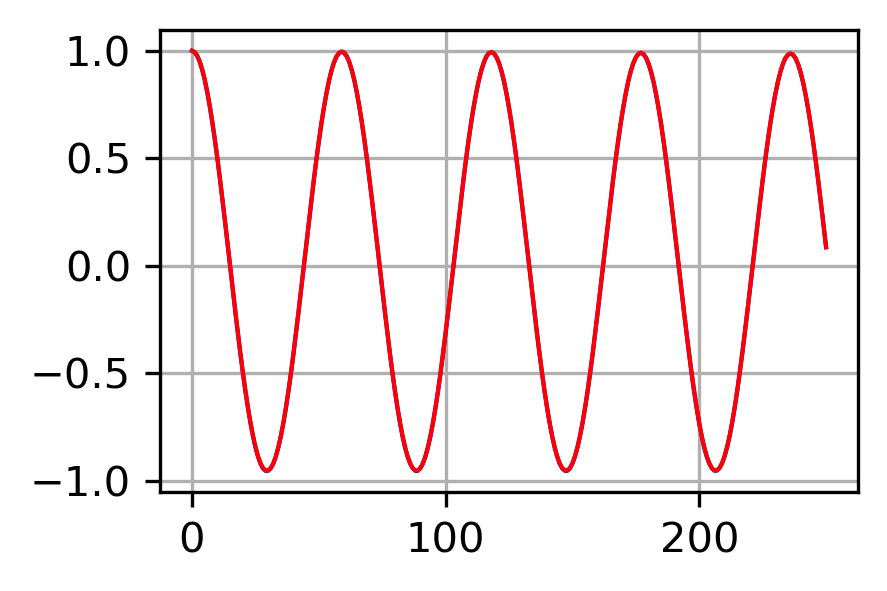

Lattice order autocorr traj :


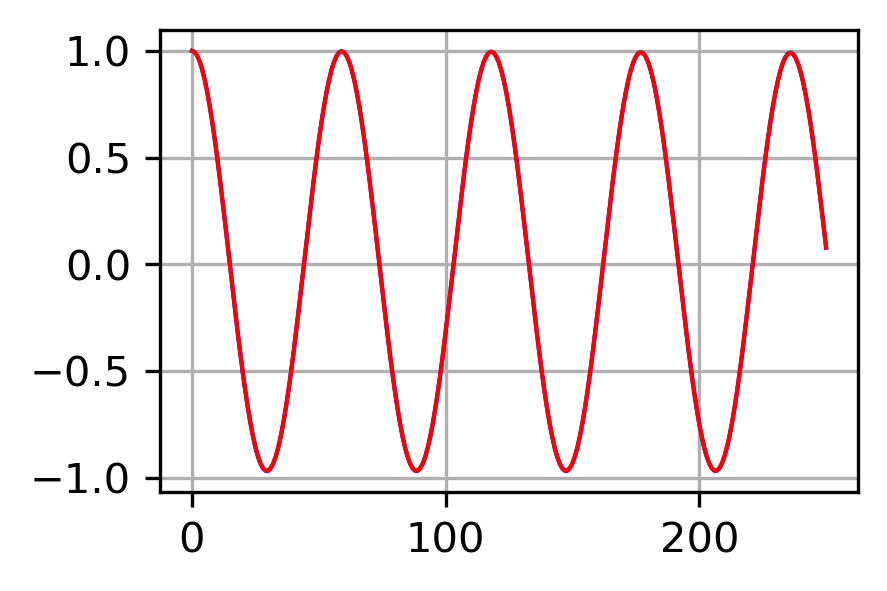

In [9]:
max_lag: int = 250

pltargs = PLTArgs(figsize=(3, 2), dpi=300, disable_text=True, labelsize=10, linewidth=1)

compare_cdw_order_autocorrelation(labels, filtered_preds, max_lag=max_lag, pltargs=pltargs)